<a href="https://colab.research.google.com/github/Love1117/Machine_learning-Projects/blob/main/Machine_Learning%20Project/05_Advanced%20Project%20(AI)/Recommendation%20System/Movies_Recommendation_System/movies_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

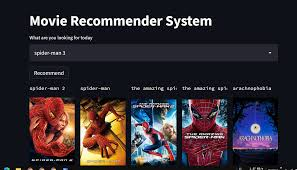

#**Project Summary:** Movie Recommendation System Using Cosine Similarity


---


#**Overview**
This project implements a content-based movie recommendation system using text vectorization and cosine similarity. Movie features such as genres, keywords, cast, or descriptions were transformed into numerical vectors, allowing the system to measure similarity between movies and recommend titles with closely related content.
The model successfully generated relevant and personalized movie recommendations based on similarity scores.


---


#**Aim of the Project**
To build an intelligent recommendation engine capable of identifying similar movies based on textual features.
To apply vectorization and cosine similarity for efficient content matching.
To demonstrate practical implementation of recommendation systems used in modern streaming platforms.

##**Import Libries**

In [234]:
import pandas as pd
import numpy as np
from google.colab import drive


##**Mount Drive**

In [235]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Load Data**

In [236]:
movies_data = pd.read_csv("/content/drive/My Drive/Datasets/imdb-movies-dataset.csv")

In [237]:
movies_data.head()

,Poster,Title,Year,Certificate,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,R,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,PG-13,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,PG-13,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,PG-13,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,R,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...


##**Data Exploration**

In [238]:
movies_data['Review'][0]

"This film, as well as the reaction to it, is a wonderful example of modern hypocrisy:The story is about an adult woman who is attracted to a young guy, 16 years younger than her, young enough to be her son, whom she sees at his boys band concert, and from people reactions starts from the movie trailer and beyond, we get praise and stories that this is the destruction of the stigma about the happiness of a woman at 40, that she can remain attractive at any age to any man, that happiness is available to anyone and it's not for us to judge someone else's love.But if this were a story about a man who, at the age of 40, attracted to a girl from a girls band, and the girl is 16 years younger than him, we would get stories about a disgusting creep who finds no other way to overcome his midlife crisis than preadatory pursue a girl, young enough to be his daughter."

In [239]:
movies_data.columns

Index(['Poster', 'Title', 'Year', 'Certificate', 'Duration (min)', 'Genre',
       'Rating', 'Metascore', 'Director', 'Cast', 'Votes', 'Description',
       'Review Count', 'Review Title', 'Review'],
      dtype='object')

In [240]:
movies = movies_data[["Poster","Title","Year","Genre","Cast","Description"]]
movies.head()

,Poster,Title,Year,Genre,Cast,Description
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,"Comedy, Drama, Romance","Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","Solène, a 40-year-old single mom, begins an un..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,"Action, Adventure, Sci-Fi","Owen Teague, Freya Allan, Kevin Durand, Peter ...","Many years after the reign of Caesar, a young ..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,"Biography, Comedy, History","Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","In 1963 Michigan, business rivals Kellogg's an..."
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,"Action, Comedy, Drama","Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...",A down-and-out stuntman must find the missing ...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,"Drama, Romance, Sport","Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","Tashi, a former tennis prodigy turned coach, t..."


In [241]:
movies["tags"] = movies["Genre"] + ". " + movies["Cast"] + ". " + movies["Description"]
movies['tags'][0]

/tmp/ipykernel_9402/4267411656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["tags"] = movies["Genre"] + ". " + movies["Cast"] + ". " + movies["Description"]


'Comedy, Drama, Romance. Anne Hathaway, Nicholas Galitzine, Ella Rubin, Annie Mumolo. Solène, a 40-year-old single mom, begins an unexpected romance with 24-year-old Hayes Campbell, the lead singer of August Moon, the hottest boy band on the planet.'

In [242]:
movies = movies.drop(columns=["Year", "Genre", "Cast", "Description"])
movies

,Poster,Title,tags
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,"Comedy, Drama, Romance. Anne Hathaway, Nichola..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,"Action, Adventure, Sci-Fi. Owen Teague, Freya ..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,"Biography, Comedy, History. Isaac Bae, Jerry S..."
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,"Action, Comedy, Drama. Ryan Gosling, Emily Blu..."
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,"Drama, Romance, Sport. Zendaya, Mike Faist, Jo..."
...,...,...,...
9995,https://m.media-amazon.com/images/M/MV5BMzg5MW...,The Greatest Show on Earth,"Drama, Family, Romance. James Stewart, Charlto..."
9996,https://m.media-amazon.com/images/M/MV5BYzA0ZG...,Berserk: Ougon Jidai-hen I - Haou no Tamago,"Animation, Action, Adventure. Hiroaki Iwanaga,..."
9997,https://m.media-amazon.com/images/M/MV5BM2U1Mj...,Is-slottet,"Mystery, Drama. Line Storesund, Hilde Nyeggen ..."
9998,https://m.media-amazon.com/images/M/MV5BMTAwOD...,Loving Pablo,"Biography, Crime, Drama. Javier Bardem, Penélo..."


In [243]:
movies.dropna(inplace=True)
movies.reset_index(drop=True, inplace=True)

In [244]:
 movies.shape

(9955, 3)

##**Importing CountVectorizer to vectorize our text**

In [245]:
from sklearn.feature_extraction.text import CountVectorizer
CV = CountVectorizer(max_features=9955,stop_words="english")
vector = CV.fit_transform(movies["tags"])

In [246]:
vector

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 218213 stored elements and shape (9955, 9955)>

##**Importing cosine_similarity to find the nearest word in meaning**

In [247]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(vector, vector)

In [248]:
def get_recommendations(title):
  idx = movies[movies["Title"]== title].index[0]
  sim_scores = sorted(list(enumerate(similarity[idx])), reverse=True,  key= lambda vector: vector[1])
  for i in sim_scores[1:11]:
    print(movies.iloc[i[0]].Title)

In [249]:
print(get_recommendations("Loving Pablo"))

The Infiltrator
The Counselor
Blow
Mr. Jones
Boys Don't Cry
Todos lo saben
Belly
City of Lies
Gotti
Law of Tehran
None


In [253]:
import joblib
import os

output_dir = "/content/drive/My Drive/Models/Advanced Project/Recommendation System/"
os.makedirs(output_dir, exist_ok=True)

joblib.dump(vector, os.path.join(output_dir, "Vector.joblib"))
joblib.dump(similarity, os.path.join(output_dir, "similarity.joblib"))

['/content/drive/My Drive/Models/Advanced Project/Recommendation System/similarity.joblib']

#**Conclusion / Deployment Summary**

When deployed, this recommendation system can:

Suggest similar movies based on user interests or selected titles.
Improve user engagement and personalization in entertainment platforms.
Serve as a foundation for scalable recommendation engines in streaming, e-commerce, or content discovery applications.

The project demonstrates strong understanding of NLP-based feature engineering and similarity-driven recommendation techniques.